<a href="https://colab.research.google.com/github/GauravChauhan88/Trader-Performance-vs.-Market-Sentiment-Analysis/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Science Intern Assignment: Trader Behavior vs Market Sentiment
Objective: Analyze how Bitcoin Fear/Greed index impacts trader performance on Hyperliquid.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
hist_df = pd.read_csv('historical_data.csv')
fg_df = pd.read_csv('fear_greed_index.csv')

# Documentation: Initial Data Check
print(f"Historical Data: {hist_df.shape[0]} rows, {hist_df.shape[1]} columns")
print(f"Sentiment Data: {fg_df.shape[0]} rows, {fg_df.shape[1]} columns")

Historical Data: 211224 rows, 16 columns
Sentiment Data: 2644 rows, 4 columns


In [4]:
# Convert dates and align datasets
hist_df['date'] = pd.to_datetime(hist_df['Timestamp IST'], dayfirst=True).dt.normalize()
fg_df['date'] = pd.to_datetime(fg_df['date'])

# Merge datasets on date
df = pd.merge(hist_df, fg_df[['date', 'classification', 'value']], on='date', how='inner')

# Simplify classification into 3 categories
df['sentiment'] = df['classification'].apply(lambda x: 'Fear' if 'Fear' in x else ('Greed' if 'Greed' in x else 'Neutral'))

In [5]:
# Aggregate daily metrics per account
daily_metrics = df.groupby(['date', 'Account', 'sentiment']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    trade_count=('Trade ID', 'count'),
    avg_size=('Size USD', 'mean')
).reset_index()

# Calculate Win Rate per account/day
win_data = df[df['Closed PnL'] != 0].groupby(['date', 'Account'])['Closed PnL'].apply(
    lambda x: (x > 0).sum() / len(x) if len(x) > 0 else 0
).reset_index(name='win_rate')

final_df = pd.merge(daily_metrics, win_data, on=['date', 'Account'])

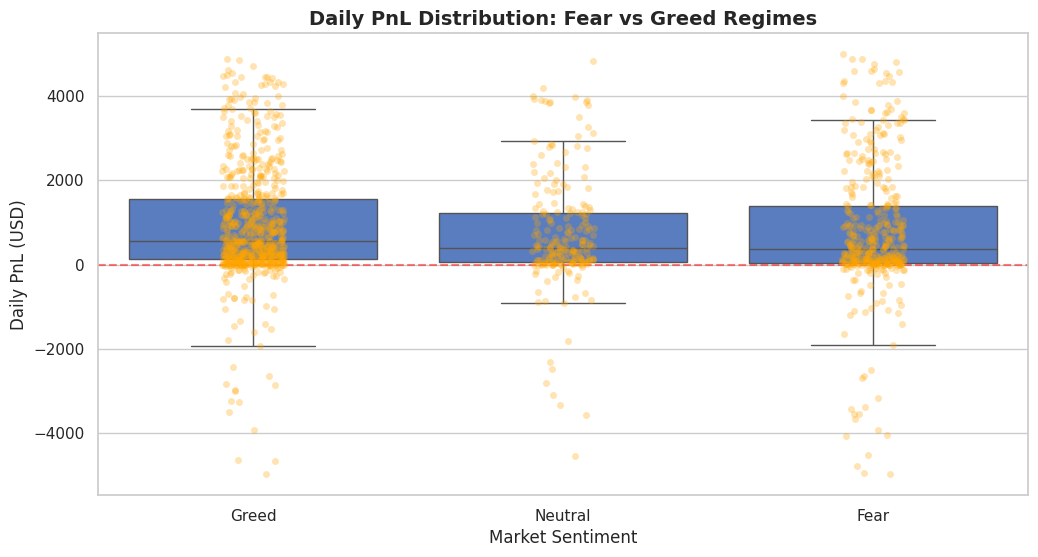

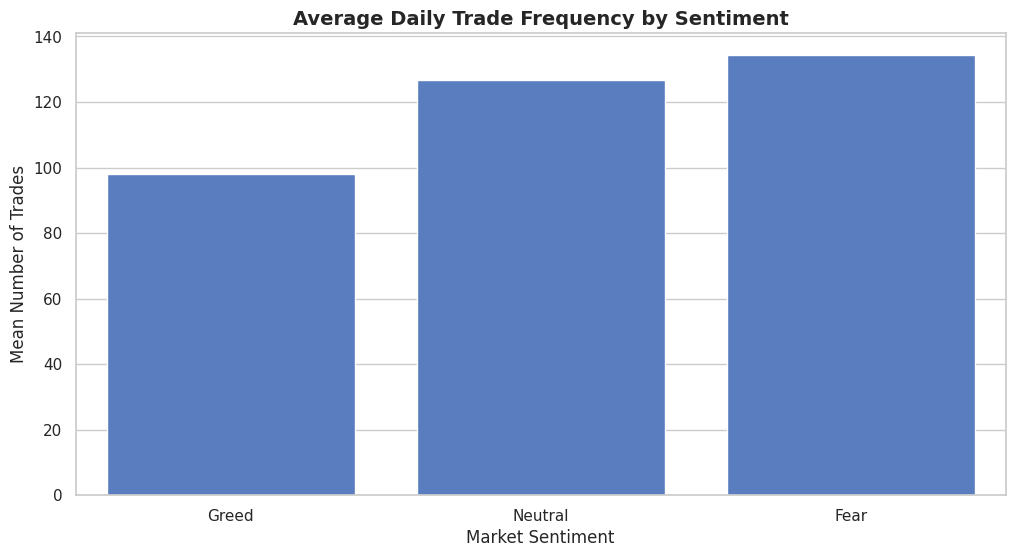

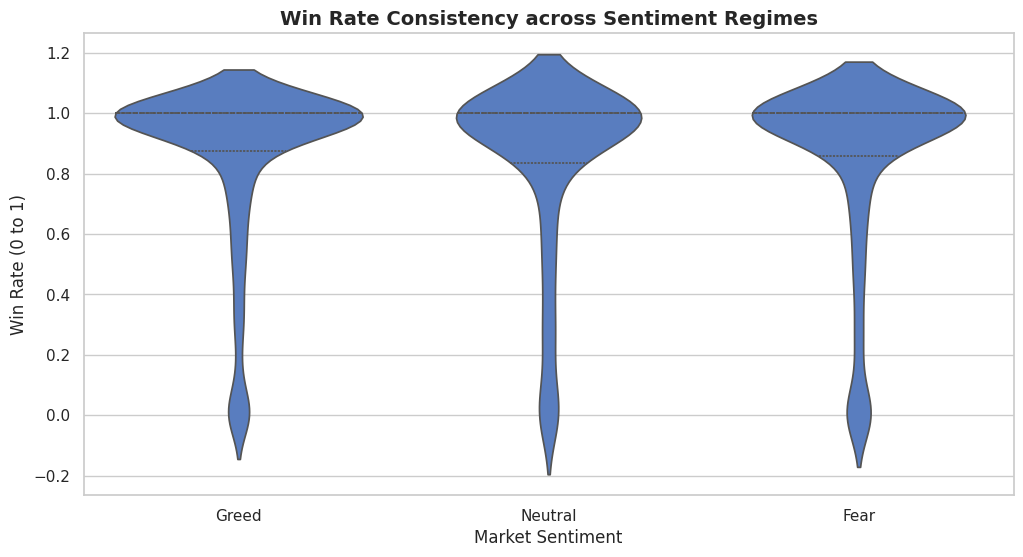

✅ Visualizations generated and saved in the 'outputs/' folder.


In [8]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set professional aesthetics
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

# --- CHART 1: PnL Distribution by Sentiment ---
plt.figure()
# Filtering PnL between -5000 and 5000 to remove extreme outliers for visual clarity
filtered_pnl = final_df[final_df['daily_pnl'].between(-5000, 5000)]

sns.boxplot(x='sentiment', y='daily_pnl', data=filtered_pnl, showfliers=False)
sns.stripplot(x='sentiment', y='daily_pnl', data=filtered_pnl, color="orange", alpha=0.3, jitter=True)

plt.title('Daily PnL Distribution: Fear vs Greed Regimes', fontsize=14, fontweight='bold')
plt.ylabel('Daily PnL (USD)')
plt.xlabel('Market Sentiment')
plt.axhline(0, color='red', linestyle='--', alpha=0.5) # Zero line for reference

plt.savefig('outputs/pnl_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# --- CHART 2: Trading Frequency (Behavioral Shift) ---
plt.figure()
sns.barplot(x='sentiment', y='trade_count', data=final_df, estimator='mean', errorbar=None)

plt.title('Average Daily Trade Frequency by Sentiment', fontsize=14, fontweight='bold')
plt.ylabel('Mean Number of Trades')
plt.xlabel('Market Sentiment')

plt.savefig('outputs/trade_frequency.png', dpi=300, bbox_inches='tight')
plt.show()

# --- CHART 3: Win Rate vs Sentiment ---
plt.figure()
sns.violinplot(x='sentiment', y='win_rate', data=final_df, inner="quart")

plt.title('Win Rate Consistency across Sentiment Regimes', fontsize=14, fontweight='bold')
plt.ylabel('Win Rate (0 to 1)')
plt.xlabel('Market Sentiment')

plt.savefig('outputs/win_rate_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
